<a href="https://colab.research.google.com/github/AkankshaB123/Optimisation/blob/main/Advertising_SLRM(Session22_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/Classroom/Ivy: Python 1-3 PM | July 2021 Pranjal Biyani | 10 July 2021/Advertising.csv', index_col = 0)
data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Identify optimal TV, Radio, Newspaper values
* Initial analysis - Row total of sales x spends, ROI/Revenue what is the % of each acquisition source

In [2]:
data.reset_index(drop=True, inplace = True)

In [3]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
#Step 2: select independent(X) and dependent variable (Y)
feature_names=['TV']

#use the list to select a subset of the original DataFrame
X = data[feature_names]

#sales
y = data['Sales']

In [5]:
#Step 3: Splitting X and Y into training and testing sets #train_size = 0.7, test_size = 0.3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=0.20)

* random_state: 1 - means both train and test get same no of rows

In [6]:
#Linear regression model to training set
from sklearn.linear_model import LinearRegression

linreg = LinearRegression() #initialising an object (linreg) of the Linear Regression Class
# Y = aX + b

# fit the model to the training data (learn the coefficients)
linreg.fit(X_train, y_train)

# y_train = aX_train = b

# solving for a and b - So I get the final equation with some values of a and b
# y = 0.0492*X + 6.799

LinearRegression()

In [7]:
print("Intercept=",linreg.intercept_)
print("Coefficient=",linreg.coef_)
# y=ax+b
# y= 0.049*X + 6.7999

Intercept= 6.799773449796853
Coefficient= [0.0492751]


In [8]:
# Sales = 0.049*(Ads on TV) + 6.7997 (Uni-variate sales equation)

# s = 0.049*1 + 6.79
# s = 0.049*2 + 6.79

# s -s = 0.049*2 - 0.049*1 = 0.049

In [9]:
# X_train, y_train
# X_test, y_test
y_pred = linreg.predict(X_test)

## **Interpreting Model Coefficients**

---

How do we interpret the TV coefficient?

* A unit increase in TV ad spending is **associated with** a 0.0492751 unit increase in Sales
* Or more clearly: An additional $1,000 spent on TV ads is **associated with** an increase in sales of 49.2751 widgets.

Note that if an increase ad spending was associated with a **decrease** in sales would be **negative**.

# Hypothesis Testing and p-values

* **null hypothesis:** There is no relationship between TV ads and Sales (Thus B1 equals zero)
* **alternative hypothesis:** There is a relationship between TV ads and Sales (this B1 is not equal to zero)

In [10]:
from sklearn.feature_selection import f_regression
fregression = f_regression(X_train, y_train) #returns Fvalues of features; p values of features
fregression

(array([280.14341559]), array([8.01212052e-37]))

### above Returns: F-value(how important feature is, p-value(8.0*12 to the power -37)

a p-value less than 0.05 is one way to decide whether there is likely a relationship between the feature and the response.


In this case, the p-value for TV is far less than 0.05, and so we **believe** that there is a relationship between TV ads and Sales.


Note that we generally ignore the p-value for the intercept.

In [12]:
#Step 5: Test the model's generalization ability using testset
# make predictions on the testing set
y_pred = linreg.predict(X_test) #never used y_test till now


In [15]:
y_pred #original - y_test

array([17.18696362, 16.77798032, 11.51540011, 20.60665526, 19.30579273,
       20.77419058, 14.84639657, 15.70871075, 10.2785952 , 17.41362906,
       14.90552669, 10.20961007, 17.37913649, 12.21017895, 17.92609005,
       12.99365298, 13.28930355, 21.12404376,  8.0612159 , 17.18203611,
       11.74699305, 10.14062494,  8.03657835, 12.09191872, 12.36293175,
       16.08320147,  8.92353007, 19.05941725, 15.01885941, 18.63072392,
       18.6208689 , 18.35478338, 14.17625527, 15.18639473, 19.03970721,
       15.91073864, 17.75855473, 13.17597083, 17.48261419,  7.76556532])

In [16]:
y_test.values

array([23.8, 16.6,  9.5, 14.8, 17.6, 25.5, 16.9, 12.9, 10.5, 17.1, 14.5,
       11.3, 17.4, 16.7, 13.4, 15.9, 12.9, 12.8,  9.5, 18.4, 10.7, 12.5,
        8.5, 11.5, 11.9, 14.9, 10.1, 18.9, 19.6, 15.9, 23.2, 11.9, 17.3,
       11.7, 20.2, 15.5, 11.5, 11. , 22.3,  7.6])

#### For Comparison y_pred x y_test

In [17]:
from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
# Step 6: Compute the performance of the model using metrics
import numpy as np
print("RMSE=", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("Rsquare=", r2_score(y_test, y_pred))

RMSE= 3.2953520791575928
Rsquare= 0.41535307148347855


RMSE - quantifiable error,
* larger the error, error in prediction;

* lower the error, lower error in prediction

R2 Score - it qualifies right features
eg.
* 17 predicted, 23 actual;
* 16 predicted, 16 actual;
* 11 predicted, 9 actual
* 20 predicted, 17 actual

R2 score:
* Trend of movement between y_pred and y_test

* Relative performance on the model on the different values of the different test dataset

In [20]:
df_predicted=pd.DataFrame()
df_predicted['Predicted']=y_pred
df_predicted.head()

,Predicted
0,17.186964
1,16.777980
2,11.515400
3,20.606655
4,19.305793


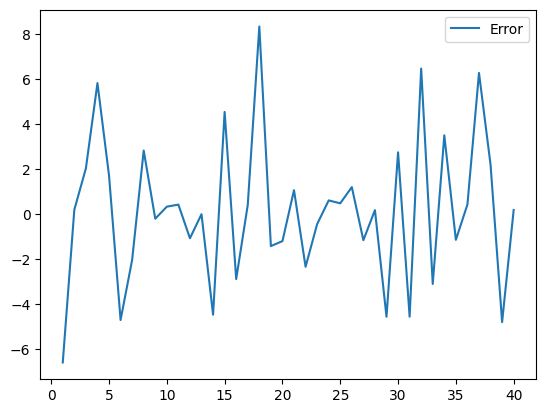

In [24]:
import matplotlib.pyplot as plt
y_error = y_pred - y_test

x = np.arange(1,len(y_pred)+1)
plt.plot(x,y_error, label = 'Error')
plt.legend()
plt.show()

Error should be random; shouldn't have a pattern

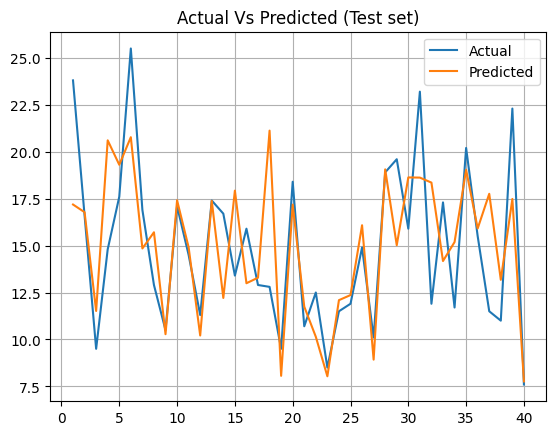

In [26]:
x=np.arange(1,len(y_test)+1)

plt.plot(x,y_test,label='Actual')
plt.plot(x,y_pred,label='Predicted')
plt.title("Actual Vs Predicted (Test set)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

Hands-on Ads Data Modelling

In [28]:
feature_names=['TV','Newspaper','Radio']

# use the list to select a subset of the original DataFrame
X=data[feature_names]

# sales
y = data.Sales

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 1, test_size=0.20)

linreg = LinearRegression()

#fit the model to the training data (learn the coefficients)
linreg.fit(X_train, y_train)

print("Intercept",linreg.intercept_)
print("Coefficient",linreg.coef_)

from sklearn.feature_selection import f_regression
fregression=f_regression(X_train, y_train) #returns Fvaluess of features; p values of features
print(fregression)

y_pred = linreg.predict(X_test)

# Step 6: Compute the performance of the model using metrics
print("RMSE=", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("Rsquare=", r2_score(y_test, y_pred))

Intercept 2.9079470208164295
Coefficient [0.0468431  0.00258619 0.17854434]
(array([280.14341559,  12.86345116,  74.61801398]), array([8.01212052e-37, 4.46264222e-04, 5.92023347e-15]))
RMSE= 1.4113417558581585
Rsquare= 0.8927605914615384


* model - Algorithm
* model.fit(X_train, y_train)
* y_pred - model.predict(X_test)
* model.evaluate(y_pred, y_test)

In [29]:
from statsmodels.api import OLS
OLS(y,X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  Sales   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.982
Method:                 Least Squares   F-statistic:                              3566.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):                   2.43e-171
Time:                        15:31:34   Log-Likelihood:                         -423.54
No. Observations:                 200   AIC:                                      853.1
Df Residuals:                     197   BIC:                                      863.0
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
TV             0.0538      0.001     40.507      0.000       0.051       0.056
Newspaper      0.0168      0.007      2.517      0.013       0.004       0.030
Radio          0.2222      0.009     23.595      0.000       0.204       0.241
==============================================================================
Omnibus:                        5.982   Durbin-Watson:                   2.038
Prob(Omnibus):                  0.050   Jarque-Bera (JB):                7.039
Skew:                          -0.232   Prob(JB):                       0.0296
Kurtosis:                       3.794   Cond. No.                         12.6
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Polynomial Regression (pending)